<a href="https://colab.research.google.com/github/kesiasilv/Trabalho-ia-risco-evasao-academica/blob/main/L%C3%B3gica_Fuzzy_e_Machine_Learning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CÉLULA 1 - INSTALAÇÃO DE BIBLIOTECAS
# Execute essa célula primeiro!
# ============================================================

!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.6 MB/s eta 0:00:00


In [2]:
# ============================================================
# CÉLULA 2 - IMPORTAR BIBLIOTECAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz
import skfuzzy.control as ctrl

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


In [3]:
##============================================================
# CÉLULA 3 - CARREGAR A BASE DE DADOS REAL
# ============================================================

# Fazendo upload do arquivo CSV no Google Colab
from google.colab import files
print("📂 Selecione o arquivo evasao_300_alunos.csv")
uploaded = files.upload()

# Lendo o arquivo
nome_arquivo = list(uploaded.keys())[0]
df = pd.read_csv(nome_arquivo)

# Deixando os nomes das colunas padronizados (sem acento, minúsculo)
df.columns = df.columns.str.strip()

print(f"\n✅ Base de dados carregada com sucesso!")
print(f"📊 Total de alunos: {len(df)}")
print(f"\n📋 Colunas encontradas:")
print(list(df.columns))
print(f"\n🔍 Primeiros 5 alunos:")
df.head()


📂 Selecione o arquivo evasao_300_alunos.csv


Saving evasao_300_alunos (2).csv to evasao_300_alunos (2).csv

✅ Base de dados carregada com sucesso!
📊 Total de alunos: 300

📋 Colunas encontradas:
['ID', 'Frequencia', 'Nota', 'Participacao_AVA', 'Atividades_Entregues', 'Reprovacoes', 'Atrasos', 'Risco_Evasao']

🔍 Primeiros 5 alunos:


,ID,Frequencia,Nota,Participacao_AVA,Atividades_Entregues,Reprovacoes,Atrasos,Risco_Evasao
0,1,68,1.0,7,40,4,5,Alto
1,2,50,2.5,35,59,4,9,Alto
2,3,63,4.6,37,21,2,4,Alto
3,4,61,0.0,24,46,4,10,Alto
4,5,67,5.4,14,22,2,6,Alto


ANÁLISE EXPLORATÓRIA DOS DADOS

📌 Estatísticas descritivas:
           ID  Frequencia    Nota  Participacao_AVA  Atividades_Entregues  \
count  300.00      300.00  300.00            300.00                300.00   
mean   150.50       68.26    5.14             47.91                 58.97   
std     86.75       15.21    2.56             27.70                 22.72   
min      1.00       40.00    0.00              0.00                 20.00   
25%     75.75       57.75    3.00             24.00                 42.00   
50%    150.50       67.00    5.40             47.00                 57.00   
75%    225.25       81.00    7.10             71.00                 79.25   
max    300.00      100.00   10.00            100.00                100.00   

       Reprovacoes  Atrasos  
count       300.00   300.00  
mean          1.91     4.63  
std           1.16     2.85  
min           0.00     0.00  
25%           1.00     2.00  
50%           2.00     5.00  
75%           3.00     7.00  
max   

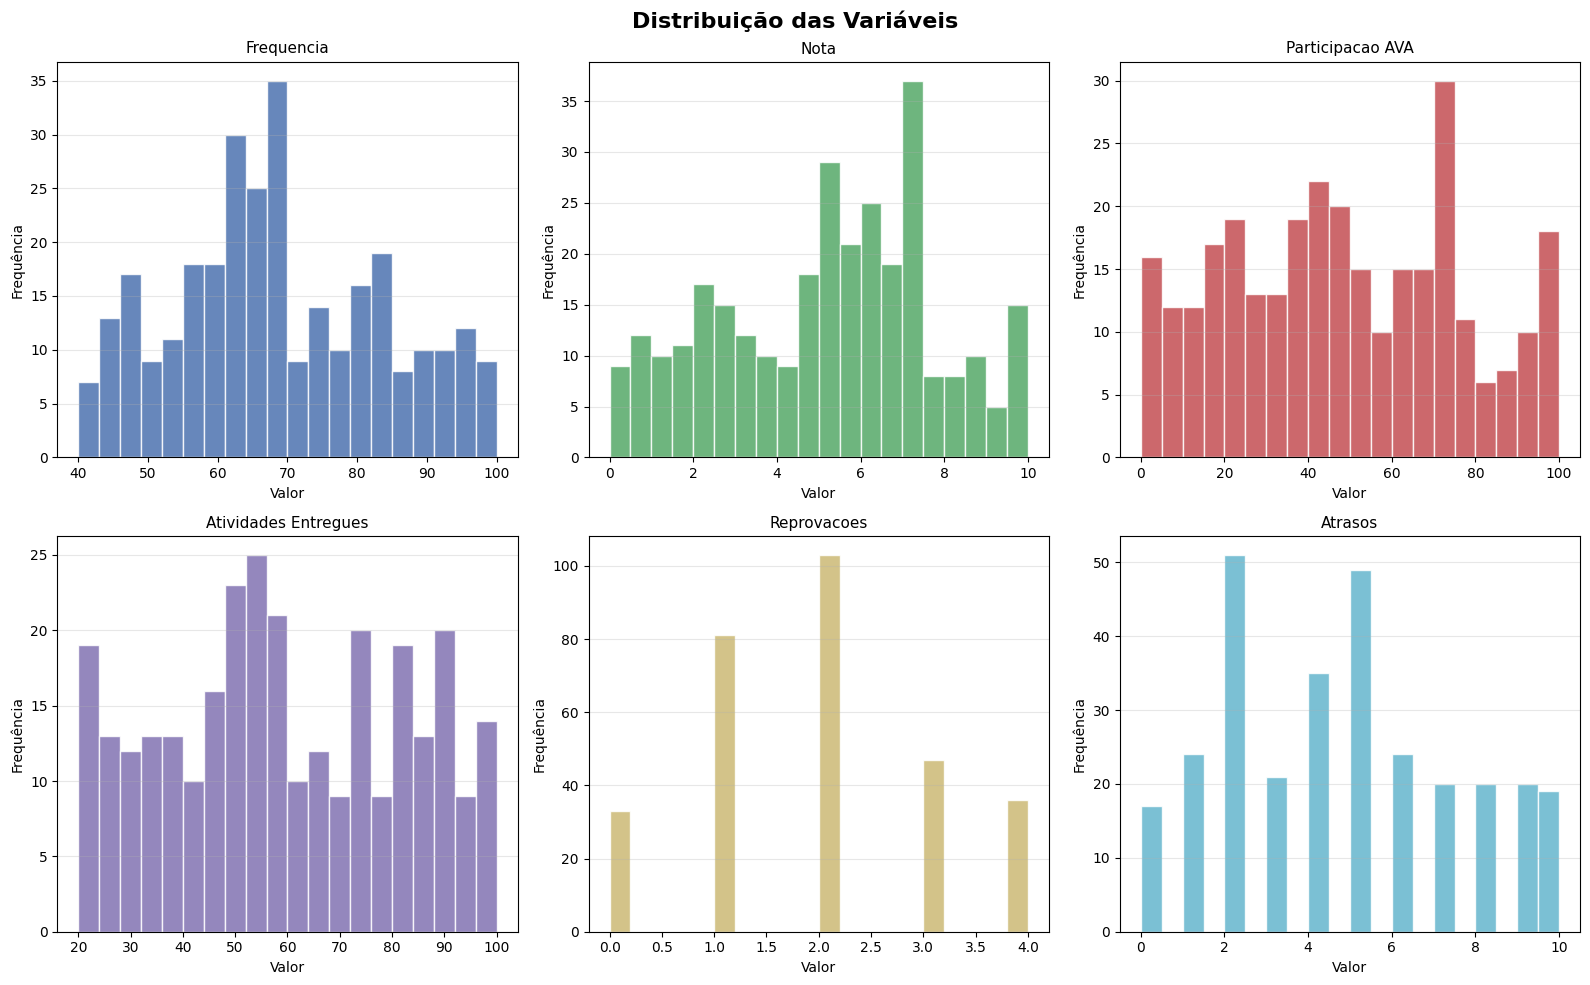

✅ Gráfico salvo como 'distribuicao_variaveis.png'


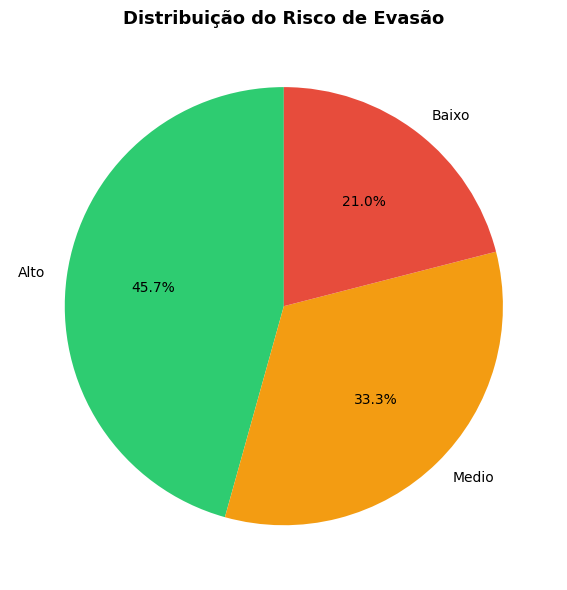

✅ Gráfico salvo como 'pizza_risco.png'


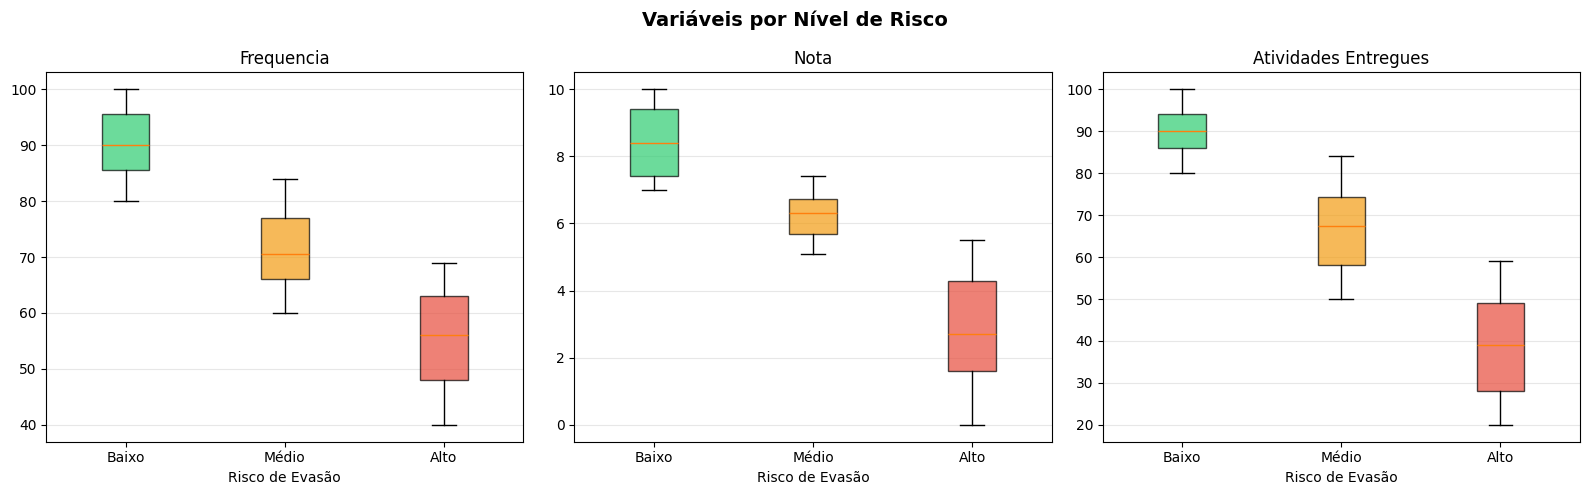

✅ Gráfico salvo como 'boxplot_risco.png'


In [4]:
# ============================================================
# CÉLULA 4 - ANÁLISE EXPLORATÓRIA DOS DADOS
# ============================================================

print("=" * 50)
print("ANÁLISE EXPLORATÓRIA DOS DADOS")
print("=" * 50)

print("\n📌 Estatísticas descritivas:")
print(df.describe().round(2))

print("\n📌 Valores ausentes por coluna:")
print(df.isnull().sum())

print("\n📌 Distribuição do Risco de Evasão:")
print(df['Risco_Evasao'].value_counts())

# --- Gráficos de distribuição ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuição das Variáveis', fontsize=16, fontweight='bold')

variaveis = ['Frequencia', 'Nota', 'Participacao_AVA',
             'Atividades_Entregues', 'Reprovacoes', 'Atrasos']
cores = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']

for i, (var, cor) in enumerate(zip(variaveis, cores)):
    ax = axes[i // 3][i % 3]
    ax.hist(df[var], bins=20, color=cor, edgecolor='white', alpha=0.85)
    ax.set_title(var.replace('_', ' '), fontsize=11)
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frequência')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('distribuicao_variaveis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo como 'distribuicao_variaveis.png'")

# --- Pizza do risco de evasão ---
fig, ax = plt.subplots(figsize=(6, 6))
contagem = df['Risco_Evasao'].value_counts()
cores_pizza = ['#2ecc71', '#f39c12', '#e74c3c']
ax.pie(contagem, labels=contagem.index, autopct='%1.1f%%',
       colors=cores_pizza, startangle=90)
ax.set_title('Distribuição do Risco de Evasão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pizza_risco.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo como 'pizza_risco.png'")

# --- Boxplot por classe de risco ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Variáveis por Nível de Risco', fontsize=14, fontweight='bold')

for i, var in enumerate(['Frequencia', 'Nota', 'Atividades_Entregues']):
    grupos = [df[df['Risco_Evasao'] == cls][var].values
              for cls in ['Baixo', 'Medio', 'Alto']]
    bp = axes[i].boxplot(grupos, labels=['Baixo', 'Médio', 'Alto'], patch_artist=True)
    for patch, cor in zip(bp['boxes'], ['#2ecc71', '#f39c12', '#e74c3c']):
        patch.set_facecolor(cor)
        patch.set_alpha(0.7)
    axes[i].set_title(var.replace('_', ' '))
    axes[i].set_xlabel('Risco de Evasão')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('boxplot_risco.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo como 'boxplot_risco.png'")

In [5]:
# ============================================================
# CÉLULA 5 - PRÉ-PROCESSAMENTO
# ============================================================

print("=" * 50)
print("PRÉ-PROCESSAMENTO")
print("=" * 50)

# Variáveis de entrada (X) e saída (y)
# Usamos todas as colunas numéricas — incluindo Atrasos que é nova!
X = df[['Frequencia', 'Nota', 'Participacao_AVA',
        'Atividades_Entregues', 'Reprovacoes', 'Atrasos']]
y = df['Risco_Evasao']

# Codificando a saída em números (Alto=0, Baixo=1, Medio=2)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"📌 Classes: {le.classes_}")

# Dividindo: 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n📌 Treino: {X_train.shape[0]} alunos")
print(f"📌 Teste:  {X_test.shape[0]} alunos")
print("✅ Pré-processamento concluído!")

PRÉ-PROCESSAMENTO
📌 Classes: ['Alto' 'Baixo' 'Medio']

📌 Treino: 240 alunos
📌 Teste:  60 alunos
✅ Pré-processamento concluído!


In [6]:
# ============================================================
# CÉLULA 6 - TREINAMENTO DA ÁRVORE DE DECISÃO
# ============================================================

print("=" * 50)
print("MODELO DE MACHINE LEARNING - ÁRVORE DE DECISÃO")
print("=" * 50)

modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

print("✅ Modelo treinado!")
print(f"📌 Profundidade da árvore: {modelo.get_depth()}")
print(f"📌 Número de folhas:       {modelo.get_n_leaves()}")

MODELO DE MACHINE LEARNING - ÁRVORE DE DECISÃO
✅ Modelo treinado!
📌 Profundidade da árvore: 5
📌 Número de folhas:       8


AVALIAÇÃO DO MODELO

📊 Acurácia: 95.00%

📊 Relatório completo:
              precision    recall  f1-score   support

        Alto       0.96      0.96      0.96        27
       Baixo       1.00      0.92      0.96        13
       Medio       0.90      0.95      0.93        20

    accuracy                           0.95        60
   macro avg       0.96      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



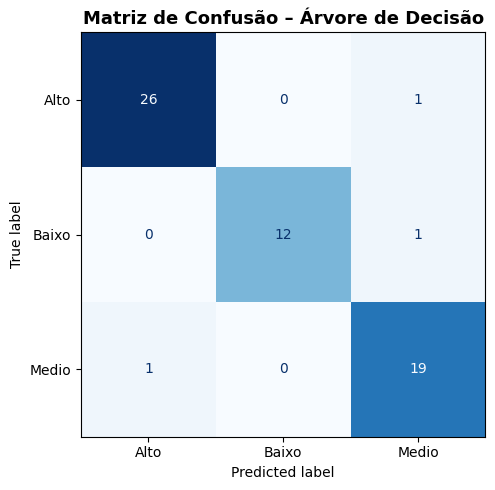

✅ Gráfico salvo como 'matriz_confusao.png'


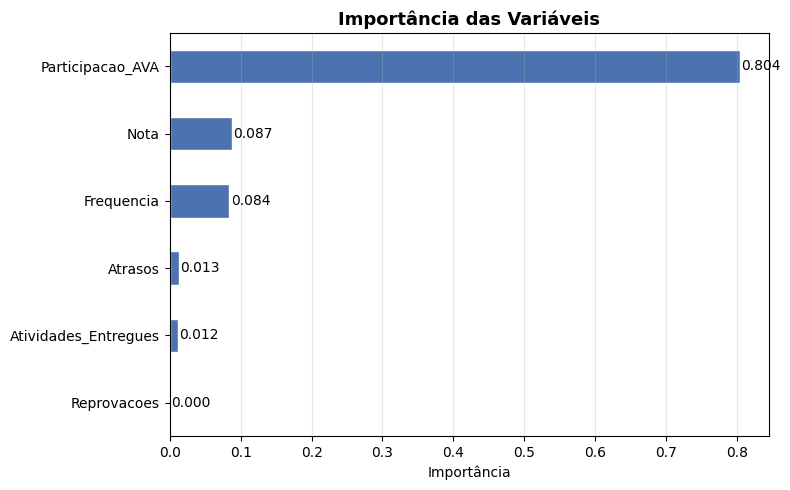

✅ Gráfico salvo como 'importancia_variaveis.png'


In [7]:
# ============================================================
# CÉLULA 7 - AVALIAÇÃO DO MODELO
# ============================================================

print("=" * 50)
print("AVALIAÇÃO DO MODELO")
print("=" * 50)

acuracia = accuracy_score(y_test, y_pred)
print(f"\n📊 Acurácia: {acuracia:.2%}")

print(f"\n📊 Relatório completo:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Matriz de confusão
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusão – Árvore de Decisão', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('matriz_confusao.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo como 'matriz_confusao.png'")

# Importância das variáveis
importancias = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))
importancias.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Importância das Variáveis', fontsize=13, fontweight='bold')
ax.set_xlabel('Importância')
ax.grid(axis='x', alpha=0.3)
for i, v in enumerate(importancias):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.savefig('importancia_variaveis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo como 'importancia_variaveis.png'")

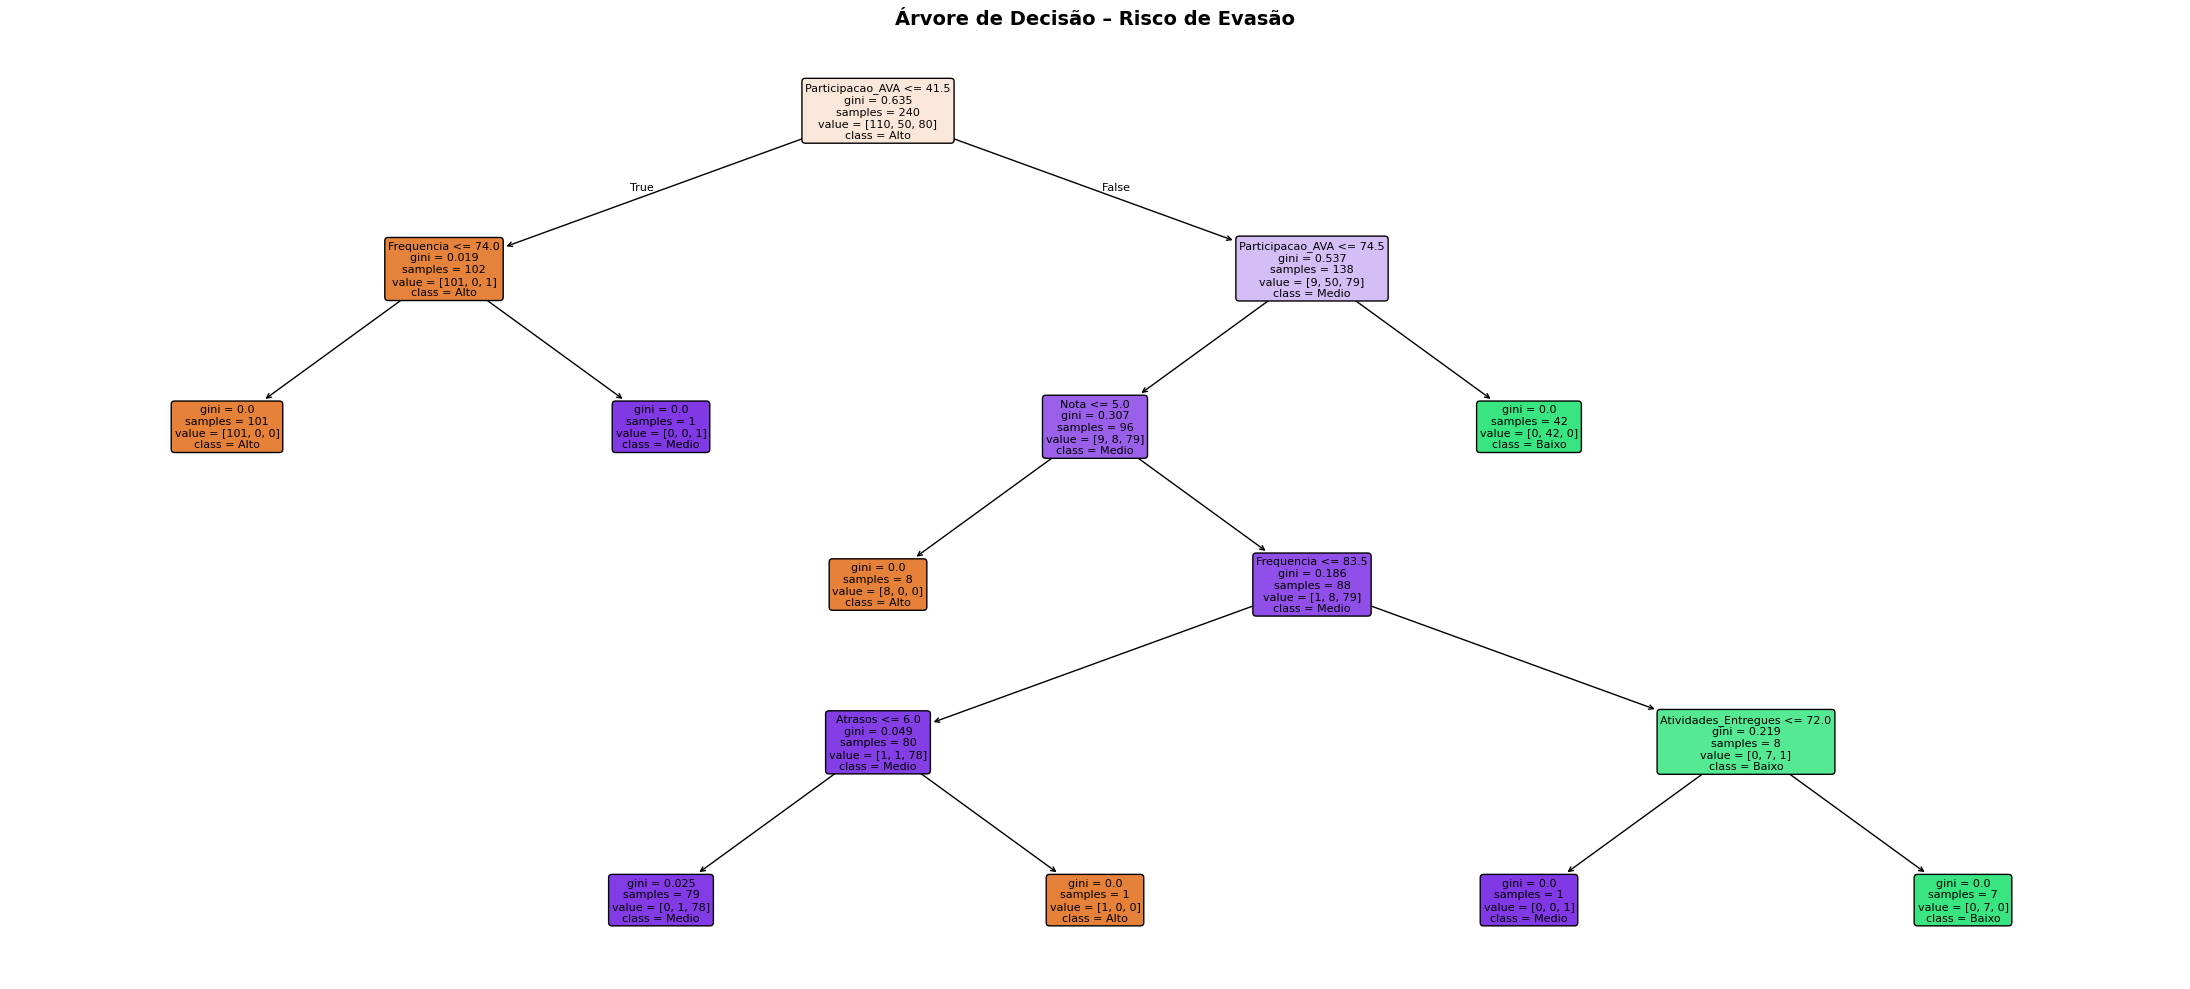


📋 Regras da Árvore (texto):
|--- Participacao_AVA <= 41.50
|   |--- Frequencia <= 74.00
|   |   |--- class: 0
|   |--- Frequencia >  74.00
|   |   |--- class: 2
|--- Participacao_AVA >  41.50
|   |--- Participacao_AVA <= 74.50
|   |   |--- Nota <= 5.00
|   |   |   |--- class: 0
|   |   |--- Nota >  5.00
|   |   |   |--- Frequencia <= 83.50
|   |   |   |   |--- Atrasos <= 6.00
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- Atrasos >  6.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- Frequencia >  83.50
|   |   |   |   |--- Atividades_Entregues <= 72.00
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- Atividades_Entregues >  72.00
|   |   |   |   |   |--- class: 1
|   |--- Participacao_AVA >  74.50
|   |   |--- class: 1



In [8]:
# ============================================================
# CÉLULA 8 - VISUALIZAÇÃO DA ÁRVORE
# ============================================================

fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True, rounded=True, fontsize=8, ax=ax
)
ax.set_title('Árvore de Decisão – Risco de Evasão', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('arvore_decisao.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Regras da Árvore (texto):")
print(export_text(modelo, feature_names=list(X.columns)))

SISTEMA DE INFERÊNCIA FUZZY
✅ Variáveis fuzzy definidas!


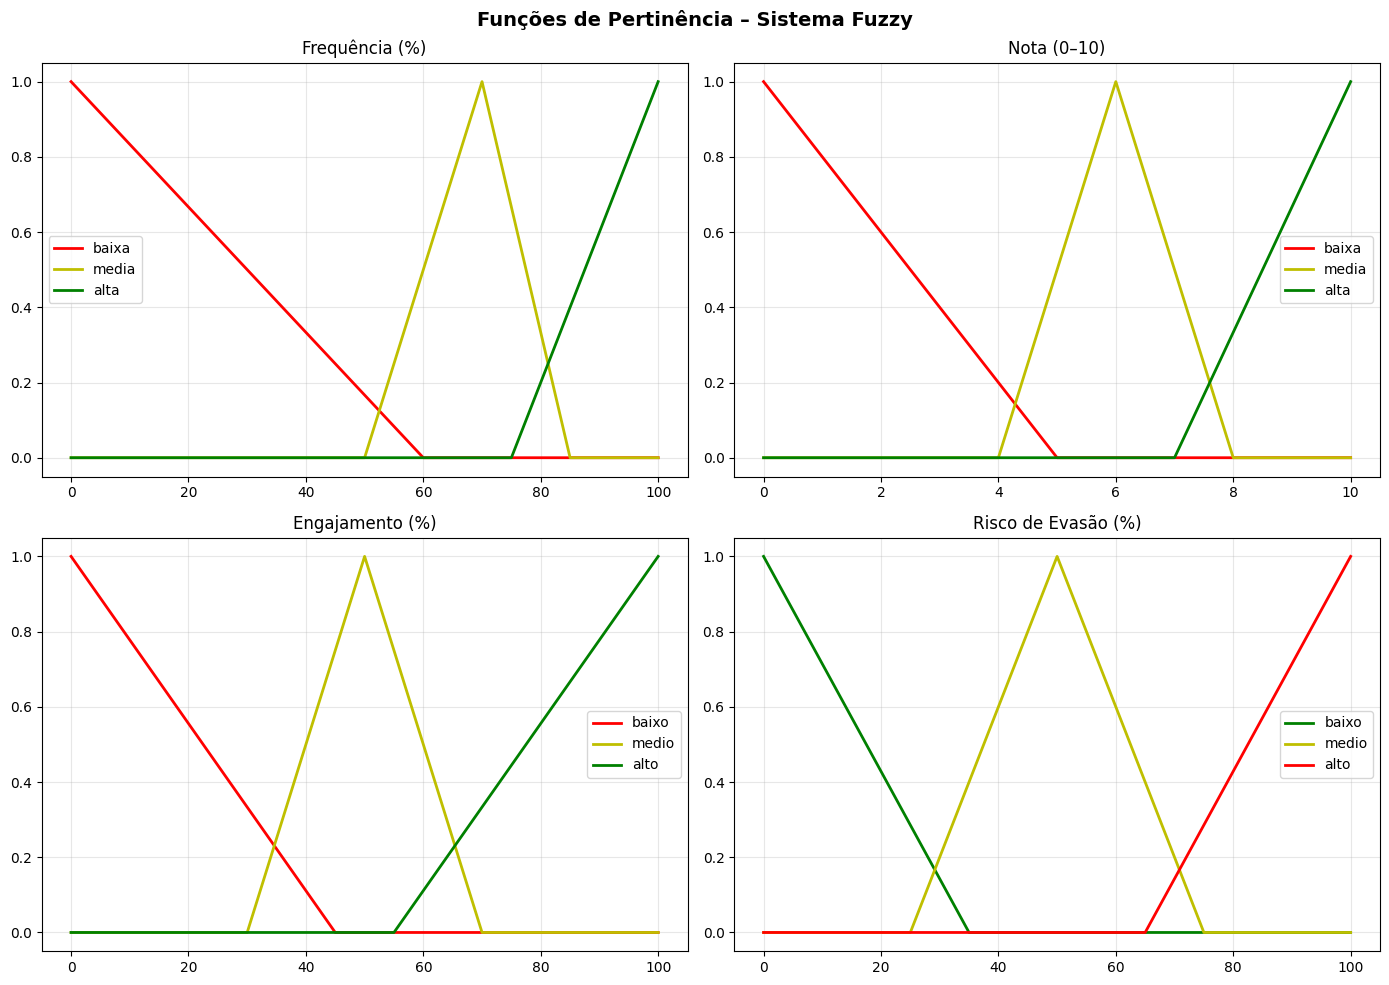

✅ Gráfico salvo como 'funcoes_pertinencia.png'


In [9]:
# ============================================================
# CÉLULA 9 - SISTEMA FUZZY
# ============================================================

print("=" * 50)
print("SISTEMA DE INFERÊNCIA FUZZY")
print("=" * 50)

# Variáveis de entrada
frequencia_fz  = ctrl.Antecedent(np.arange(0, 101, 1),    'frequencia')
nota_fz        = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'nota')
engajamento_fz = ctrl.Antecedent(np.arange(0, 101, 1),    'engajamento')

# Variável de saída
risco_fz = ctrl.Consequent(np.arange(0, 101, 1), 'risco_evasao')
risco_fz.defuzzify_method = 'centroid'

# Funções de pertinência
frequencia_fz['baixa'] = fuzz.trimf(frequencia_fz.universe, [0,   0,  60])
frequencia_fz['media'] = fuzz.trimf(frequencia_fz.universe, [50,  70, 85])
frequencia_fz['alta']  = fuzz.trimf(frequencia_fz.universe, [75, 100, 100])

nota_fz['baixa'] = fuzz.trimf(nota_fz.universe, [0,   0,   5])
nota_fz['media'] = fuzz.trimf(nota_fz.universe, [4,   6,   8])
nota_fz['alta']  = fuzz.trimf(nota_fz.universe, [7,  10,  10])

engajamento_fz['baixo'] = fuzz.trimf(engajamento_fz.universe, [0,   0,  45])
engajamento_fz['medio'] = fuzz.trimf(engajamento_fz.universe, [30,  50, 70])
engajamento_fz['alto']  = fuzz.trimf(engajamento_fz.universe, [55, 100, 100])

risco_fz['baixo'] = fuzz.trimf(risco_fz.universe, [0,   0,  35])
risco_fz['medio'] = fuzz.trimf(risco_fz.universe, [25,  50, 75])
risco_fz['alto']  = fuzz.trimf(risco_fz.universe, [65, 100, 100])

print("✅ Variáveis fuzzy definidas!")

# Gráfico das funções de pertinência
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Funções de Pertinência – Sistema Fuzzy', fontsize=14, fontweight='bold')

ax = axes[0][0]
ax.plot(frequencia_fz.universe, fuzz.trimf(frequencia_fz.universe, [0,   0,  60]),  'r-', lw=2, label='baixa')
ax.plot(frequencia_fz.universe, fuzz.trimf(frequencia_fz.universe, [50,  70, 85]),  'y-', lw=2, label='media')
ax.plot(frequencia_fz.universe, fuzz.trimf(frequencia_fz.universe, [75, 100, 100]), 'g-', lw=2, label='alta')
ax.set_title('Frequência (%)'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0][1]
ax.plot(nota_fz.universe, fuzz.trimf(nota_fz.universe, [0, 0,  5]), 'r-', lw=2, label='baixa')
ax.plot(nota_fz.universe, fuzz.trimf(nota_fz.universe, [4, 6,  8]), 'y-', lw=2, label='media')
ax.plot(nota_fz.universe, fuzz.trimf(nota_fz.universe, [7, 10, 10]),'g-', lw=2, label='alta')
ax.set_title('Nota (0–10)'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1][0]
ax.plot(engajamento_fz.universe, fuzz.trimf(engajamento_fz.universe, [0,   0,  45]),  'r-', lw=2, label='baixo')
ax.plot(engajamento_fz.universe, fuzz.trimf(engajamento_fz.universe, [30,  50, 70]),  'y-', lw=2, label='medio')
ax.plot(engajamento_fz.universe, fuzz.trimf(engajamento_fz.universe, [55, 100, 100]), 'g-', lw=2, label='alto')
ax.set_title('Engajamento (%)'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1][1]
ax.plot(risco_fz.universe, fuzz.trimf(risco_fz.universe, [0,   0,  35]),  'g-', lw=2, label='baixo')
ax.plot(risco_fz.universe, fuzz.trimf(risco_fz.universe, [25,  50, 75]),  'y-', lw=2, label='medio')
ax.plot(risco_fz.universe, fuzz.trimf(risco_fz.universe, [65, 100, 100]), 'r-', lw=2, label='alto')
ax.set_title('Risco de Evasão (%)'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('funcoes_pertinencia.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo como 'funcoes_pertinencia.png'")

In [10]:
# ============================================================
# CÉLULA 10 - REGRAS FUZZY
# ============================================================

regra1 = ctrl.Rule(frequencia_fz['baixa'] & nota_fz['baixa'],        risco_fz['alto'])
regra2 = ctrl.Rule(frequencia_fz['baixa'] & engajamento_fz['baixo'], risco_fz['alto'])
regra3 = ctrl.Rule(frequencia_fz['media'] & nota_fz['baixa'],        risco_fz['medio'])
regra4 = ctrl.Rule(frequencia_fz['media'] & engajamento_fz['medio'], risco_fz['medio'])
regra5 = ctrl.Rule(frequencia_fz['alta']  & nota_fz['alta'],         risco_fz['baixo'])
regra6 = ctrl.Rule(frequencia_fz['alta']  & engajamento_fz['alto'],  risco_fz['baixo'])
regra7 = ctrl.Rule(nota_fz['baixa']       & engajamento_fz['baixo'], risco_fz['alto'])
regra8 = ctrl.Rule(nota_fz['alta']        & engajamento_fz['medio'], risco_fz['baixo'])

sistema_ctrl = ctrl.ControlSystem([regra1, regra2, regra3, regra4,
                                    regra5, regra6, regra7, regra8])
sistema = ctrl.ControlSystemSimulation(sistema_ctrl)

print("✅ Sistema fuzzy criado com 8 regras!")
print("""
📋 Regras:
  R1: SE frequência é baixa  E nota é baixa       → risco ALTO
  R2: SE frequência é baixa  E engajamento é baixo → risco ALTO
  R3: SE frequência é média  E nota é baixa        → risco MÉDIO
  R4: SE frequência é média  E engajamento é médio → risco MÉDIO
  R5: SE frequência é alta   E nota é alta         → risco BAIXO
  R6: SE frequência é alta   E engajamento é alto  → risco BAIXO
  R7: SE nota é baixa        E engajamento é baixo → risco ALTO
  R8: SE nota é alta         E engajamento é médio → risco BAIXO
""")

✅ Sistema fuzzy criado com 8 regras!

📋 Regras:
  R1: SE frequência é baixa  E nota é baixa       → risco ALTO
  R2: SE frequência é baixa  E engajamento é baixo → risco ALTO
  R3: SE frequência é média  E nota é baixa        → risco MÉDIO
  R4: SE frequência é média  E engajamento é médio → risco MÉDIO
  R5: SE frequência é alta   E nota é alta         → risco BAIXO
  R6: SE frequência é alta   E engajamento é alto  → risco BAIXO
  R7: SE nota é baixa        E engajamento é baixo → risco ALTO
  R8: SE nota é alta         E engajamento é médio → risco BAIXO



In [11]:
# ============================================================
# CÉLULA 11 - FUNÇÕES AUXILIARES
# ============================================================

def calcular_engajamento(participacao_ava, atividades_entregues, atrasos):
    """
    Combina participação no AVA, atividades entregues e atrasos
    em um único índice de engajamento (0 a 100).
    Atrasos penalizam o engajamento.
    """
    atrasos_norm = min(atrasos * 10, 100)   # transforma atrasos (0-10) em escala 0-100
    engaj = (participacao_ava * 0.45) + (atividades_entregues * 0.40) - (atrasos_norm * 0.15)
    return float(np.clip(engaj, 0, 100))

def calcular_risco_fuzzy(freq, nota, engaj):
    """
    Aplica o sistema fuzzy e retorna (valor 0-100, classificação textual).
    """
    try:
        sistema.input['frequencia']  = float(np.clip(freq,  0, 100))
        sistema.input['nota']        = float(np.clip(nota,  0,  10))
        sistema.input['engajamento'] = float(np.clip(engaj, 0, 100))
        sistema.compute()
        valor = sistema.output['risco_evasao']
        classe = 'Baixo' if valor < 35 else ('Medio' if valor < 65 else 'Alto')
        return round(valor, 2), classe
    except Exception:
        return 50.0, 'Medio'

print("✅ Funções auxiliares definidas!")
print("""
💡 O engajamento combina 3 colunas da base:
   - Participacao_AVA    (peso 45%)
   - Atividades_Entregues (peso 40%)
   - Atrasos             (penaliza -15%)
""")


✅ Funções auxiliares definidas!

💡 O engajamento combina 3 colunas da base:
   - Participacao_AVA    (peso 45%)
   - Atividades_Entregues (peso 40%)
   - Atrasos             (penaliza -15%)



In [12]:
# ============================================================
# CÉLULA 12 - INTEGRAÇÃO: APLICANDO FUZZY EM TODOS OS ALUNOS
# ============================================================

print("=" * 50)
print("INTEGRAÇÃO: APLICANDO FUZZY EM TODOS OS ALUNOS")
print("=" * 50)

# Calculando o engajamento de cada aluno usando as 3 colunas
df['Engajamento'] = df.apply(
    lambda row: calcular_engajamento(
        row['Participacao_AVA'],
        row['Atividades_Entregues'],
        row['Atrasos']
    ),
    axis=1
)

# Aplicando o sistema fuzzy em cada aluno
resultados_fuzzy = df.apply(
    lambda row: calcular_risco_fuzzy(row['Frequencia'], row['Nota'], row['Engajamento']),
    axis=1
)
df['risco_fuzzy_valor']  = [r[0] for r in resultados_fuzzy]
df['risco_fuzzy_classe'] = [r[1] for r in resultados_fuzzy]

# Previsão do modelo ML para todos os alunos
X_completo = df[['Frequencia', 'Nota', 'Participacao_AVA',
                 'Atividades_Entregues', 'Reprovacoes', 'Atrasos']]
df['risco_ml_classe'] = le.inverse_transform(modelo.predict(X_completo))

print("✅ Integração concluída!")
print("\n📋 Amostra dos resultados (10 primeiros alunos):")
print(df[['Frequencia', 'Nota', 'Engajamento',
          'Risco_Evasao', 'risco_ml_classe', 'risco_fuzzy_classe']].head(10).to_string())

INTEGRAÇÃO: APLICANDO FUZZY EM TODOS OS ALUNOS
✅ Integração concluída!

📋 Amostra dos resultados (10 primeiros alunos):
   Frequencia  Nota  Engajamento Risco_Evasao risco_ml_classe risco_fuzzy_classe
0          68   1.0        11.65         Alto            Alto               Alto
1          50   2.5        25.85         Alto            Alto               Alto
2          63   4.6        19.05         Alto            Alto              Medio
3          61   0.0        14.20         Alto            Alto               Alto
4          67   5.4         6.10         Alto            Alto              Medio
5          68   5.2        44.45        Medio           Medio              Medio
6          88   7.0        68.55        Baixo           Baixo              Baixo
7          71   6.2        51.00        Medio           Medio              Medio
8          43   1.7         0.00         Alto            Alto               Alto
9          91   9.8        74.75        Baixo           Baixo         

COMPARAÇÃO: MACHINE LEARNING vs FUZZY

📊 Taxa de concordância ML x Fuzzy: 82.67%

📊 Machine Learning:
risco_ml_classe
Alto     137
Medio    102
Baixo     61
Name: count, dtype: int64

📊 Sistema Fuzzy:
risco_fuzzy_classe
Medio    150
Alto      88
Baixo     62
Name: count, dtype: int64

📊 Rótulo real (base de dados):
Risco_Evasao
Alto     137
Medio    100
Baixo     63
Name: count, dtype: int64


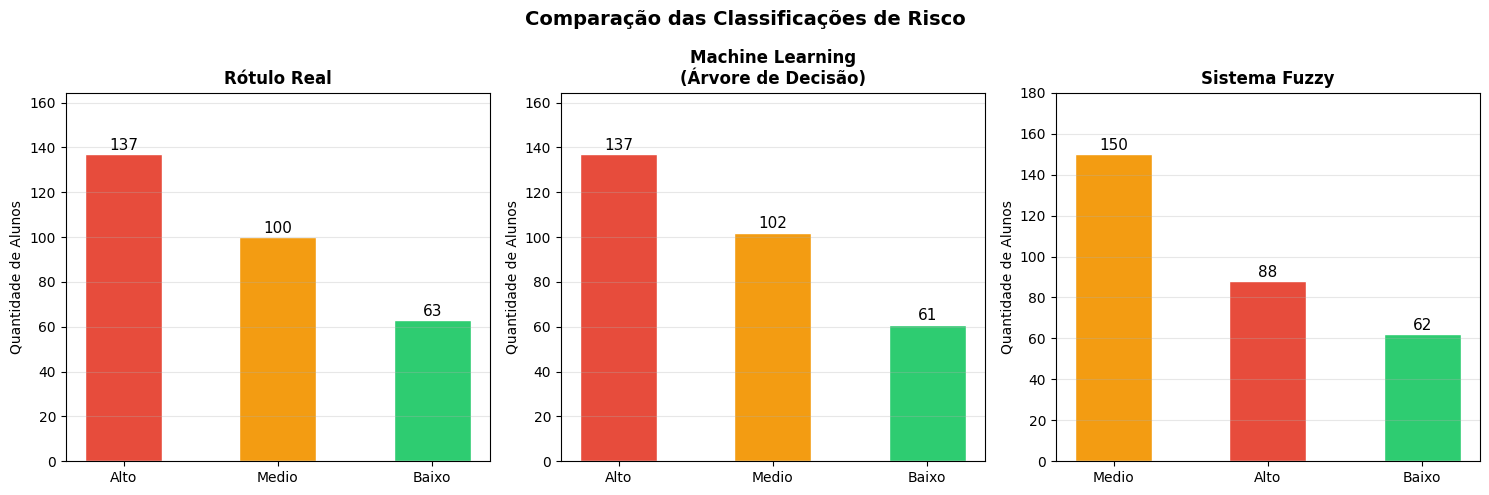

✅ Gráfico salvo como 'comparacao_classificacoes.png'


In [13]:
# ============================================================
# CÉLULA 13 - COMPARAÇÃO ML vs FUZZY
# ============================================================

print("=" * 50)
print("COMPARAÇÃO: MACHINE LEARNING vs FUZZY")
print("=" * 50)

df['concordancia'] = df['risco_ml_classe'] == df['risco_fuzzy_classe']
taxa_concordancia  = df['concordancia'].mean()
print(f"\n📊 Taxa de concordância ML x Fuzzy: {taxa_concordancia:.2%}")

print("\n📊 Machine Learning:")
print(df['risco_ml_classe'].value_counts())
print("\n📊 Sistema Fuzzy:")
print(df['risco_fuzzy_classe'].value_counts())
print("\n📊 Rótulo real (base de dados):")
print(df['Risco_Evasao'].value_counts())

# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparação das Classificações de Risco', fontsize=14, fontweight='bold')
cores_risco = {'Alto': '#e74c3c', 'Medio': '#f39c12', 'Baixo': '#2ecc71'}

for ax, coluna, titulo in zip(
    axes,
    ['Risco_Evasao', 'risco_ml_classe', 'risco_fuzzy_classe'],
    ['Rótulo Real', 'Machine Learning\n(Árvore de Decisão)', 'Sistema Fuzzy']
):
    contagem = df[coluna].value_counts()
    barras = ax.bar(contagem.index, contagem.values,
                    color=[cores_risco.get(c, '#888') for c in contagem.index],
                    edgecolor='white', width=0.5)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('Quantidade de Alunos')
    ax.set_ylim(0, contagem.max() * 1.2)
    for b in barras:
        ax.text(b.get_x() + b.get_width()/2, b.get_height()+2,
                str(int(b.get_height())), ha='center', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('comparacao_classificacoes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico salvo como 'comparacao_classificacoes.png'")

In [14]:
# ============================================================
# CÉLULA 14 - CASOS DE TESTE (exemplos individuais)
# ============================================================

print("=" * 50)
print("CASOS DE TESTE – EXEMPLOS INDIVIDUAIS")
print("=" * 50)

# Formato: (Frequencia, Nota, Participacao_AVA, Atividades_Entregues, Reprovacoes, Atrasos, Descrição)
casos = [
    (96, 10.0, 99, 93, 0, 1,  "Aluno exemplar"),
    (68,  5.2, 43, 74, 2, 3,  "Desempenho mediano"),
    (43,  1.7,  5, 23, 3, 8,  "Aluno em risco"),
    (91,  9.9, 98, 94, 0, 0,  "Alto desempenho"),
    (44,  0.0,  0, 59, 2, 10, "Situação crítica"),
]

print(f"\n{'Caso':<22} {'Freq':>5} {'Nota':>5} {'AVA':>5} {'Atv':>5} {'Rep':>4} {'Atr':>4} | {'ML':>7} | {'Fuzzy':>7}")
print("-" * 80)

for freq, nota, ava, atv, rep, atr, descricao in casos:
    # Previsão ML
    entrada = pd.DataFrame([[freq, nota, ava, atv, rep, atr]],
                           columns=['Frequencia', 'Nota', 'Participacao_AVA',
                                    'Atividades_Entregues', 'Reprovacoes', 'Atrasos'])
    pred_ml = le.inverse_transform(modelo.predict(entrada))[0]

    # Previsão Fuzzy
    engaj = calcular_engajamento(ava, atv, atr)
    _, pred_fuzzy = calcular_risco_fuzzy(freq, nota, engaj)

    print(f"{descricao:<22} {freq:>5} {nota:>5.1f} {ava:>5} {atv:>5} {rep:>4} {atr:>4} | {pred_ml:>7} | {pred_fuzzy:>7}")

CASOS DE TESTE – EXEMPLOS INDIVIDUAIS

Caso                    Freq  Nota   AVA   Atv  Rep  Atr |      ML |   Fuzzy
--------------------------------------------------------------------------------
Aluno exemplar            96  10.0    99    93    0    1 |   Baixo |   Baixo
Desempenho mediano        68   5.2    43    74    2    3 |   Medio |   Medio
Aluno em risco            43   1.7     5    23    3    8 |    Alto |    Alto
Alto desempenho           91   9.9    98    94    0    0 |   Baixo |   Baixo
Situação crítica          44   0.0     0    59    2   10 |    Alto |    Alto


In [15]:
# ============================================================
# CÉLULA 15 - RESUMO FINAL
# ============================================================

acuracia = accuracy_score(y_test, modelo.predict(X_test))

print("\n" + "=" * 55)
print("    RESUMO FINAL DO TRABALHO")
print("=" * 55)
print(f"""
📚 TEMA: Risco de Evasão Acadêmica

📊 BASE DE DADOS:
   Total de alunos:      {len(df)}
   Variáveis de entrada: 6 (Frequencia, Nota, Participacao_AVA,
                            Atividades_Entregues, Reprovacoes, Atrasos)

🤖 MACHINE LEARNING (Árvore de Decisão):
   Acurácia no teste:    {acuracia:.2%}
   Profundidade:         {modelo.get_depth()}
   Variável mais import: {X.columns[np.argmax(modelo.feature_importances_)]}

🔀 SISTEMA FUZZY:
   Entradas:  frequência, nota, engajamento
   Saída:     risco de evasão (0–100)
   Regras:    8 regras SE...ENTÃO
   Método:    Defuzzificação por centróide

📈 COMPARAÇÃO ML x FUZZY:
   Taxa de concordância: {taxa_concordancia:.2%}

📁 ARQUIVOS GERADOS:
   ✅ distribuicao_variaveis.png
   ✅ pizza_risco.png
   ✅ boxplot_risco.png
   ✅ matriz_confusao.png
   ✅ importancia_variaveis.png
   ✅ arvore_decisao.png
   ✅ funcoes_pertinencia.png
   ✅ comparacao_classificacoes.png
""")
print("🎓 Trabalho concluído com sucesso!")



    RESUMO FINAL DO TRABALHO

📚 TEMA: Risco de Evasão Acadêmica

📊 BASE DE DADOS:
   Total de alunos:      300
   Variáveis de entrada: 6 (Frequencia, Nota, Participacao_AVA,
                            Atividades_Entregues, Reprovacoes, Atrasos)

🤖 MACHINE LEARNING (Árvore de Decisão):
   Acurácia no teste:    95.00%
   Profundidade:         5
   Variável mais import: Participacao_AVA

🔀 SISTEMA FUZZY:
   Entradas:  frequência, nota, engajamento
   Saída:     risco de evasão (0–100)
   Regras:    8 regras SE...ENTÃO
   Método:    Defuzzificação por centróide

📈 COMPARAÇÃO ML x FUZZY:
   Taxa de concordância: 82.67%

📁 ARQUIVOS GERADOS:
   ✅ distribuicao_variaveis.png
   ✅ pizza_risco.png
   ✅ boxplot_risco.png
   ✅ matriz_confusao.png
   ✅ importancia_variaveis.png
   ✅ arvore_decisao.png
   ✅ funcoes_pertinencia.png
   ✅ comparacao_classificacoes.png

🎓 Trabalho concluído com sucesso!
